# VKR2: модель без lambda-признаков и сравнение шума

В этой тетрадке сохранен рабочий минимум из `VKR1` и добавлен отдельный эксперимент:

- из входного вектора удалены `lambda1`, `lambda2`, потому что `lambda = omega ** 2`;
- массы `m1`, `m2` предсказываются в логарифмической шкале;
- используется облегченная модель `11/9 -> 64 -> 64 -> 32 -> 4`;
- сравниваются два уровня шума во входных признаках: `1%` и `5%`.

In [1]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

print("OK: environment variables set")

OK: environment variables set


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cpu


## Прямая задача и генерация синтетических данных

In [3]:
def compute_features(x1, m1, x2, m2, l=1.0):
    """
    Прямая задача для упрощённой постановки.

    Вход:
        x1, m1 — координата и масса первой точки на ребре e1
        x2, m2 — координата и масса второй точки на ребре e2
        l      — длина каждой нити, в работе берём l = 1

    Выход:
        X — входной вектор нейросети из 11 признаков
        Y — истинный вектор параметров: (x1, m1, x2, m2)
    """

    if not (0 < x1 < l):
        raise ValueError("x1 должен быть внутри интервала (0, l)")
    if not (0 < x2 < l):
        raise ValueError("x2 должен быть внутри интервала (0, l)")
    if not (m1 > 0 and m2 > 0):
        raise ValueError("Массы должны быть положительными")

    # Коэффициенты из вывода прямой задачи
    a1 = 1.0 / x1
    a2 = 1.0 / x2
    a3 = 1.0 / l

    b1 = 1.0 / (l - x1)
    b2 = 1.0 / (l - x2)

    S = a1 + a2 + a3

    # Матрица жёсткости после исключения безмассовой вершины V0
    K = np.array([
        [a1 + b1 - (a1 * a1) / S, -(a1 * a2) / S],
        [-(a1 * a2) / S, a2 + b2 - (a2 * a2) / S]
    ], dtype=np.float64)

    # Матрица масс диагональная: M = diag(m1, m2)
    inv_sqrt_M = np.diag([1.0 / np.sqrt(m1), 1.0 / np.sqrt(m2)])

    # Переход к симметричной задаче:
    # M^{-1/2} K M^{-1/2} q = lambda q
    C = inv_sqrt_M @ K @ inv_sqrt_M

    lambdas, q_vectors = np.linalg.eigh(C)

    # Сортируем собственные значения по возрастанию
    idx = np.argsort(lambdas)
    lambdas = lambdas[idx]
    q_vectors = q_vectors[:, idx]

    if np.any(lambdas <= 0):
        raise ValueError("Получены неположительные собственные значения")

    omega1 = np.sqrt(lambdas[0])
    omega2 = np.sqrt(lambdas[1])

    lambda1 = lambdas[0]
    lambda2 = lambdas[1]

    # Собственные формы в координатах A1, A2
    A_vectors = inv_sqrt_M @ q_vectors

    theta_all = []

    for k in range(2):
        A1 = A_vectors[0, k]
        A2 = A_vectors[1, k]

        # Амплитуда в центральной вершине V0
        A0 = (a1 * A1 + a2 * A2) / S

        # Углы малых наклонов считаем пропорциональными наклонам участков у границ
        theta1 = -b1 * A1
        theta2 = -b2 * A2
        theta3 = -a3 * A0

        theta = np.array([theta1, theta2, theta3], dtype=np.float64)

        # Нормировка, чтобы форма не зависела от масштаба амплитуды
        theta = theta / np.linalg.norm(theta)

        # Исправляем произвольный знак собственной формы
        main_index = np.argmax(np.abs(theta))
        if theta[main_index] < 0:
            theta = -theta

        theta_all.extend(theta.tolist())

    X = np.array([
        omega1,
        omega2,
        lambda1,
        lambda2,
        omega2 / omega1,
        theta_all[0],
        theta_all[1],
        theta_all[2],
        theta_all[3],
        theta_all[4],
        theta_all[5]
    ], dtype=np.float64)

    Y = np.array([x1, m1, x2, m2], dtype=np.float64)

    return X, Y

In [4]:
def generate_dataset(
    n_samples=10000,
    l=1.0,
    eps=0.05,
    m_min=0.1,
    m_max=5.0,
    noise_level=0.00,
    random_state=42
):
    """
    Генерация синтетической обучающей выборки.

    n_samples   — число объектов
    l           — длина нити
    eps         — отступ от концов нити, чтобы не брать x слишком близко к 0 и l
    m_min       — минимальная масса
    m_max       — максимальная масса
    noise_level — уровень шума в признаках X
    """

    rng = np.random.default_rng(random_state)

    X_list = []
    Y_list = []

    bad_count = 0

    for _ in range(n_samples):
        x1 = rng.uniform(eps, l - eps)
        x2 = rng.uniform(eps, l - eps)

        m1 = rng.uniform(m_min, m_max)
        m2 = rng.uniform(m_min, m_max)

        try:
            X, Y = compute_features(x1, m1, x2, m2, l=l)

            if noise_level > 0:
                X_noisy = X.copy()

                # Малый относительный шум на спектральные признаки
                X_noisy[:5] = X_noisy[:5] * (1.0 + rng.normal(0.0, noise_level, size=5))

                # Малый аддитивный шум на углы
                X_noisy[5:] = X_noisy[5:] + rng.normal(0.0, noise_level, size=6)

                X = X_noisy

            X_list.append(X)
            Y_list.append(Y)

        except Exception:
            bad_count += 1

    X_array = np.array(X_list, dtype=np.float32)
    Y_array = np.array(Y_list, dtype=np.float32)

    return X_array, Y_array, bad_count

In [5]:
feature_names = [
    "omega1",
    "omega2",
    "lambda1",
    "lambda2",
    "omega2_div_omega1",
    "theta1_mode1",
    "theta2_mode1",
    "theta3_mode1",
    "theta1_mode2",
    "theta2_mode2",
    "theta3_mode2",
]

target_names = [
    "x1",
    "m1",
    "x2",
    "m2",
]

lambda_indices = [2, 3]

feature_names_no_lambda = [
    name for index, name in enumerate(feature_names)
    if index not in lambda_indices
]

print("Features without lambda:")
print(feature_names_no_lambda)

Features without lambda:
['omega1', 'omega2', 'omega2_div_omega1', 'theta1_mode1', 'theta2_mode1', 'theta3_mode1', 'theta1_mode2', 'theta2_mode2', 'theta3_mode2']


In [6]:
X, Y, bad_count = generate_dataset(
    n_samples=10000,
    l=1.0,
    eps=0.05,
    m_min=0.1,
    m_max=5.0,
    noise_level=0.00,
    random_state=SEED,
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Bad objects:", bad_count)

X shape: (10000, 11)
Y shape: (10000, 4)
Bad objects: 0


## Модель и функции эксперимента

In [7]:
class PhysicsRegressionNetSmall(nn.Module):
    def __init__(self, input_size=9, output_size=4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, output_size),
        )

    def forward(self, x):
        return self.net(x)

In [8]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=200,
    learning_rate=0.001,
    weight_decay=0.0001,
    patience=30,
):
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()

        train_loss_sum = 0.0
        train_count = 0

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, Y_batch)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * X_batch.size(0)
            train_count += X_batch.size(0)

        train_loss = train_loss_sum / train_count

        model.eval()

        val_loss_sum = 0.0
        val_count = 0

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                predictions = model(X_batch)
                loss = criterion(predictions, Y_batch)

                val_loss_sum += loss.item() * X_batch.size(0)
                val_count += X_batch.size(0)

        val_loss = val_loss_sum / val_count

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss = {train_loss:.6f} | "
                f"val_loss = {val_loss:.6f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

In [9]:
def predict_scaled(model, X_scaled):
    model.eval()

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        predictions_scaled = model(X_tensor).cpu().numpy()

    return predictions_scaled


def remove_lambda_features(X):
    return np.delete(X, lambda_indices, axis=1).astype(np.float32)


def add_measurement_noise(X_without_lambda, noise_level=0.01, random_state=SEED):
    rng = np.random.default_rng(random_state)

    X_noisy = X_without_lambda.copy().astype(np.float32)

    # После удаления lambda первые 3 признака: omega1, omega2, omega2 / omega1.
    spectral_count = 3

    X_noisy[:, :spectral_count] = X_noisy[:, :spectral_count] * (
        1.0 + rng.normal(0.0, noise_level, size=X_noisy[:, :spectral_count].shape)
    )

    X_noisy[:, spectral_count:] = X_noisy[:, spectral_count:] + rng.normal(
        0.0,
        noise_level,
        size=X_noisy[:, spectral_count:].shape,
    )

    return X_noisy.astype(np.float32)


def make_log_mass_targets(Y):
    Y_log = Y.copy().astype(np.float32)
    Y_log[:, 1] = np.log(Y_log[:, 1])
    Y_log[:, 3] = np.log(Y_log[:, 3])
    return Y_log


def inverse_log_mass_targets(Y_log):
    Y_original = Y_log.copy()
    Y_original[:, 1] = np.exp(Y_original[:, 1])
    Y_original[:, 3] = np.exp(Y_original[:, 3])
    return Y_original


def clip_predictions(Y_pred):
    Y_clipped = Y_pred.copy()
    Y_clipped[:, 0] = np.clip(Y_clipped[:, 0], 0.05, 0.95)
    Y_clipped[:, 1] = np.clip(Y_clipped[:, 1], 0.1, 5.0)
    Y_clipped[:, 2] = np.clip(Y_clipped[:, 2], 0.05, 0.95)
    Y_clipped[:, 3] = np.clip(Y_clipped[:, 3], 0.1, 5.0)
    return Y_clipped

In [10]:
def build_extended_metrics(Y_true, Y_pred):
    abs_errors = np.abs(Y_pred - Y_true)

    mse_by_target = mean_squared_error(
        Y_true,
        Y_pred,
        multioutput="raw_values",
    )

    mae_by_target = mean_absolute_error(
        Y_true,
        Y_pred,
        multioutput="raw_values",
    )

    rmse_by_target = np.sqrt(mse_by_target)
    r2_by_target = r2_score(Y_true, Y_pred, multioutput="raw_values")

    median_abs_error = np.median(abs_errors, axis=0)
    p95_abs_error = np.percentile(abs_errors, 95, axis=0)
    max_abs_error = np.max(abs_errors, axis=0)

    ranges = np.array([
        0.95 - 0.05,
        5.0 - 0.1,
        0.95 - 0.05,
        5.0 - 0.1,
    ])

    metrics_df = pd.DataFrame({
        "parameter": target_names,
        "MSE": mse_by_target,
        "RMSE": rmse_by_target,
        "MAE": mae_by_target,
        "Median AE": median_abs_error,
        "95% AE": p95_abs_error,
        "Max AE": max_abs_error,
        "R2": r2_by_target,
        "MAE, % range": mae_by_target / ranges * 100,
        "RMSE, % range": rmse_by_target / ranges * 100,
        "95% AE, % range": p95_abs_error / ranges * 100,
    })

    return metrics_df


def build_relative_mass_metrics(Y_true, Y_pred):
    relative_error_m1 = np.abs(Y_pred[:, 1] - Y_true[:, 1]) / Y_true[:, 1] * 100
    relative_error_m2 = np.abs(Y_pred[:, 3] - Y_true[:, 3]) / Y_true[:, 3] * 100

    return pd.DataFrame({
        "parameter": ["m1", "m2"],
        "Mean relative error, %": [
            relative_error_m1.mean(),
            relative_error_m2.mean(),
        ],
        "Median relative error, %": [
            np.median(relative_error_m1),
            np.median(relative_error_m2),
        ],
        "95% relative error, %": [
            np.percentile(relative_error_m1, 95),
            np.percentile(relative_error_m2, 95),
        ],
        "Max relative error, %": [
            relative_error_m1.max(),
            relative_error_m2.max(),
        ],
    })


def make_error_bins_report(true_values, pred_values, parameter_name, bins):
    errors = pred_values - true_values
    abs_errors = np.abs(errors)

    temp_df = pd.DataFrame({
        "true": true_values,
        "pred": pred_values,
        "error": errors,
        "abs_error": abs_errors,
    })

    temp_df["bin"] = pd.cut(
        temp_df["true"],
        bins=bins,
        include_lowest=True,
    )

    report = temp_df.groupby("bin", observed=False).agg(
        count=("true", "count"),
        mean_true=("true", "mean"),
        mean_pred=("pred", "mean"),
        mean_error=("error", "mean"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        p95_abs_error=("abs_error", lambda x: np.percentile(x, 95)),
    ).reset_index()

    report.insert(0, "parameter", parameter_name)

    return report

In [11]:
def run_noise_experiment(noise_level, random_state=SEED):
    print("=" * 70)
    print(f"Noise level: {noise_level * 100:.1f}%")

    X_without_lambda = remove_lambda_features(X)
    X_noisy = add_measurement_noise(
        X_without_lambda,
        noise_level=noise_level,
        random_state=random_state,
    )

    Y_log = make_log_mass_targets(Y)

    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X_noisy,
        Y_log,
        test_size=0.30,
        random_state=SEED,
    )

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp,
        Y_temp,
        test_size=0.50,
        random_state=SEED,
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled = x_scaler.transform(X_val).astype(np.float32)
    X_test_scaled = x_scaler.transform(X_test).astype(np.float32)

    Y_train_scaled = y_scaler.fit_transform(Y_train).astype(np.float32)
    Y_val_scaled = y_scaler.transform(Y_val).astype(np.float32)

    train_dataset = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(Y_train_scaled, dtype=torch.float32),
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val_scaled, dtype=torch.float32),
        torch.tensor(Y_val_scaled, dtype=torch.float32),
    )

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=256,
        shuffle=True,
        generator=generator,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=256,
        shuffle=False,
    )

    torch.manual_seed(SEED)
    model = PhysicsRegressionNetSmall(input_size=X_noisy.shape[1], output_size=4).to(device)

    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=200,
        learning_rate=0.001,
        weight_decay=0.0001,
        patience=30,
    )

    Y_pred_scaled = predict_scaled(model, X_test_scaled)
    Y_pred_log = y_scaler.inverse_transform(Y_pred_scaled)

    Y_pred = inverse_log_mass_targets(Y_pred_log)
    Y_true = inverse_log_mass_targets(Y_test)

    Y_pred = clip_predictions(Y_pred)

    extended_metrics = build_extended_metrics(Y_true, Y_pred)
    relative_mass_metrics = build_relative_mass_metrics(Y_true, Y_pred)

    m_bins = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 4.5, 5.0]

    mass_bins = pd.concat(
        [
            make_error_bins_report(Y_true[:, 1], Y_pred[:, 1], "m1", m_bins),
            make_error_bins_report(Y_true[:, 3], Y_pred[:, 3], "m2", m_bins),
        ],
        axis=0,
    )

    summary = {
        "noise_level": noise_level,
        "input_features": X_noisy.shape[1],
        "x1_MAE": extended_metrics.loc[extended_metrics["parameter"] == "x1", "MAE"].iloc[0],
        "m1_MAE": extended_metrics.loc[extended_metrics["parameter"] == "m1", "MAE"].iloc[0],
        "x2_MAE": extended_metrics.loc[extended_metrics["parameter"] == "x2", "MAE"].iloc[0],
        "m2_MAE": extended_metrics.loc[extended_metrics["parameter"] == "m2", "MAE"].iloc[0],
        "m1_mean_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m1",
            "Mean relative error, %",
        ].iloc[0],
        "m2_mean_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m2",
            "Mean relative error, %",
        ].iloc[0],
        "m1_p95_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m1",
            "95% relative error, %",
        ].iloc[0],
        "m2_p95_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m2",
            "95% relative error, %",
        ].iloc[0],
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
    }

    return {
        "noise_level": noise_level,
        "model": model,
        "history": history,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "Y_true": Y_true,
        "Y_pred": Y_pred,
        "extended_metrics": extended_metrics,
        "relative_mass_metrics": relative_mass_metrics,
        "mass_bins": mass_bins,
        "summary": summary,
    }

## Эксперимент 1: шум 1%

In [12]:
experiment_noise_1 = run_noise_experiment(
    noise_level=0.01,
    random_state=101,
)

experiment_noise_1["extended_metrics"]

Noise level: 1.0%


Epoch 001 | train_loss = 0.869647 | val_loss = 0.647397


Epoch 010 | train_loss = 0.048315 | val_loss = 0.046705


Epoch 020 | train_loss = 0.024755 | val_loss = 0.023476


Epoch 030 | train_loss = 0.018588 | val_loss = 0.018061


...

Epoch 170 | train_loss = 0.009562 | val_loss = 0.010793


Epoch 180 | train_loss = 0.009729 | val_loss = 0.011026


Epoch 190 | train_loss = 0.009736 | val_loss = 0.011151


Epoch 200 | train_loss = 0.009663 | val_loss = 0.011244


,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,x1,0.000576,0.024000,0.016317,0.012169,0.043293,0.181797,0.991261,1.813003,2.666675,4.810370
1,m1,0.068398,0.261529,0.149166,0.083795,0.498708,2.013159,0.965363,3.044203,5.337330,10.177717
2,x2,0.000548,0.023418,0.016245,0.012031,0.044718,0.226761,0.992032,1.805003,2.602049,4.968649
3,m2,0.055383,0.235336,0.140477,0.077864,0.516400,1.838217,0.972672,2.866868,4.802774,10.538775


In [13]:
experiment_noise_1["relative_mass_metrics"]

,parameter,"Mean relative error, %","Median relative error, %","95% relative error, %","Max relative error, %"
0,m1,6.400130,3.784055,22.886122,111.311424
1,m2,6.399333,3.633699,22.966166,112.154945


In [14]:
experiment_noise_1["mass_bins"]

,parameter,bin,count,mean_true,mean_pred,mean_error,mae,median_abs_error,p95_abs_error
0,m1,"(0.099, 0.5]",100,0.299056,0.302819,0.003763,0.025117,0.011823,0.081701
1,m1,"(0.5, 1.0]",157,0.743129,0.744324,0.001194,0.060487,0.026896,0.281196
2,m1,"(1.0, 2.0]",285,1.495921,1.471999,-0.023922,0.116227,0.066628,0.437790
3,m1,"(2.0, 3.0]",320,2.508557,2.476355,-0.032202,0.143050,0.092702,0.458181
4,m1,"(3.0, 4.0]",320,3.527115,3.416983,-0.110132,0.188062,0.108664,0.717485
5,m1,"(4.0, 4.5]",155,4.271733,4.144354,-0.127379,0.206797,0.137371,0.644177
6,m1,"(4.5, 5.0]",163,4.737108,4.538322,-0.198786,0.249120,0.195260,0.689256
0,m2,"(0.099, 0.5]",133,0.284199,0.289440,0.005242,0.030564,0.013983,0.141569
1,m2,"(0.5, 1.0]",125,0.765365,0.813056,0.047691,0.085417,0.029438,0.488063
2,m2,"(1.0, 2.0]",310,1.482850,1.495875,0.013025,0.106409,0.051856,0.500705


## Эксперимент 2: шум 5%

In [15]:
experiment_noise_5 = run_noise_experiment(
    noise_level=0.05,
    random_state=105,
)

experiment_noise_5["extended_metrics"]

Noise level: 5.0%
Epoch 001 | train_loss = 0.873929 | val_loss = 0.657873


Epoch 010 | train_loss = 0.100570 | val_loss = 0.101129


Epoch 020 | train_loss = 0.079647 | val_loss = 0.083296


Epoch 030 | train_loss = 0.073285 | val_loss = 0.077352


Epoch 040 | train_loss = 0.068761 | val_loss = 0.075194


...

Epoch 120 | train_loss = 0.059313 | val_loss = 0.070914


Epoch 130 | train_loss = 0.058357 | val_loss = 0.070643


Epoch 140 | train_loss = 0.058836 | val_loss = 0.073560


Epoch 150 | train_loss = 0.057230 | val_loss = 0.070945
Early stopping at epoch 151


,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,x1,0.004128,0.064246,0.046442,0.035226,0.131222,0.359012,0.937376,5.160248,7.138492,14.580243
1,m1,0.204530,0.452250,0.301205,0.197027,0.985410,3.285773,0.896424,6.147031,9.229588,20.110416
2,x2,0.004027,0.063458,0.046343,0.035254,0.130922,0.498546,0.941491,5.149179,7.050894,14.546927
3,m2,0.213640,0.462212,0.299944,0.187215,1.030699,2.644294,0.894581,6.121303,9.432894,21.034664


In [16]:
experiment_noise_5["relative_mass_metrics"]

,parameter,"Mean relative error, %","Median relative error, %","95% relative error, %","Max relative error, %"
0,m1,13.841395,8.547442,48.229008,130.565186
1,m2,13.676448,8.409782,46.572685,176.280746


In [17]:
experiment_noise_5["mass_bins"]

,parameter,bin,count,mean_true,mean_pred,mean_error,mae,median_abs_error,p95_abs_error
0,m1,"(0.099, 0.5]",100,0.299056,0.357676,0.058619,0.077853,0.029795,0.319609
1,m1,"(0.5, 1.0]",157,0.743129,0.830998,0.087869,0.173037,0.095621,0.562603
2,m1,"(1.0, 2.0]",285,1.495921,1.550220,0.054299,0.221428,0.138421,0.719985
3,m1,"(2.0, 3.0]",320,2.508557,2.546912,0.038355,0.295728,0.212268,0.985411
4,m1,"(3.0, 4.0]",320,3.527115,3.306771,-0.220344,0.375208,0.253904,1.170912
5,m1,"(4.0, 4.5]",155,4.271733,3.994746,-0.276987,0.398941,0.288915,1.193308
6,m1,"(4.5, 5.0]",163,4.737108,4.302584,-0.434524,0.473692,0.407012,1.253147
0,m2,"(0.099, 0.5]",133,0.284199,0.308881,0.024683,0.061404,0.036499,0.213258
1,m2,"(0.5, 1.0]",125,0.765365,0.815024,0.049659,0.147448,0.087261,0.452503
2,m2,"(1.0, 2.0]",310,1.482850,1.537347,0.054498,0.247181,0.155798,0.816283


## Итоговое сравнение

In [18]:
comparison_df = pd.DataFrame([
    experiment_noise_1["summary"],
    experiment_noise_5["summary"],
])

comparison_df

,noise_level,input_features,x1_MAE,m1_MAE,x2_MAE,m2_MAE,m1_mean_relative_error_percent,m2_mean_relative_error_percent,m1_p95_relative_error_percent,m2_p95_relative_error_percent,final_train_loss,final_val_loss
0,0.01,9,0.016317,0.149166,0.016245,0.140477,6.400130,6.399333,22.886122,22.966166,0.009663,0.011244
1,0.05,9,0.046442,0.301205,0.046343,0.299944,13.841395,13.676448,48.229008,46.572685,0.057647,0.070786


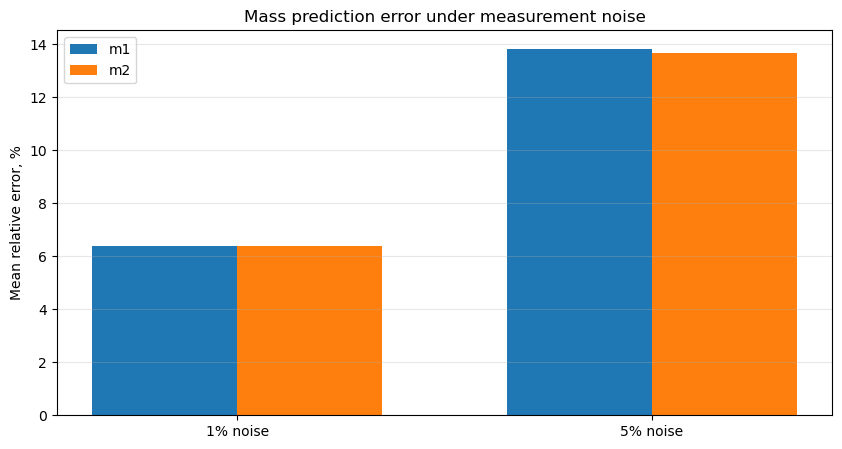

In [19]:
plt.figure(figsize=(10, 5))

x = np.arange(2)
width = 0.35

plt.bar(
    x - width / 2,
    comparison_df["m1_mean_relative_error_percent"],
    width,
    label="m1",
)

plt.bar(
    x + width / 2,
    comparison_df["m2_mean_relative_error_percent"],
    width,
    label="m2",
)

plt.xticks(x, ["1% noise", "5% noise"])
plt.ylabel("Mean relative error, %")
plt.title("Mass prediction error under measurement noise")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

## Сохранение моделей эксперимента

In [20]:
def save_noise_experiment_checkpoint(experiment, filename):
    checkpoint = {
        "model_state_dict": experiment["model"].state_dict(),
        "x_scaler": experiment["x_scaler"],
        "y_scaler": experiment["y_scaler"],
        "feature_names": feature_names_no_lambda,
        "target_names": target_names,
        "uses_log_mass": True,
        "removed_features": ["lambda1", "lambda2"],
        "noise_level": experiment["noise_level"],
        "architecture": "9-64-64-32-4",
        "summary": experiment["summary"],
    }

    torch.save(checkpoint, filename)
    print("Saved:", filename)


save_noise_experiment_checkpoint(
    experiment_noise_1,
    "physics_regression_net_small_log_no_lambda_noise_1pct_checkpoint.pt",
)

save_noise_experiment_checkpoint(
    experiment_noise_5,
    "physics_regression_net_small_log_no_lambda_noise_5pct_checkpoint.pt",
)

Saved: physics_regression_net_small_log_no_lambda_noise_1pct_checkpoint.pt
Saved: physics_regression_net_small_log_no_lambda_noise_5pct_checkpoint.pt


## Краткий вывод

После удаления lambda1, lambda2 входной вектор уменьшился с 11 до 9 признаков. При шуме 1% модель сохраняет приемлемую точность: средняя относительная ошибка масс составляет примерно 6.40% для m1 и 6.40% для m2, а 95-й перцентиль относительной ошибки около 22.9%.

При шуме 5% качество заметно ухудшается: средняя относительная ошибка масс возрастает примерно до 13.84% для m1 и 13.68% для m2, а 95-й перцентиль достигает 48.2% и 46.6%. Это показывает, что модель чувствительна к сильному шуму во входных спектральных признаках и формах колебаний.

Для текста ВКР разумный вывод: удаление lambda методически оправдано, поскольку эти признаки зависят от частот как lambda = omega ** 2, а добавление шума делает эксперимент ближе к измерительной постановке. Уровень шума 1% можно считать рабочим стресс-тестом, а 5% показывает границу устойчивости модели.

## Полные метрики для сравнения

Здесь собраны те же подробные метрики, которые использовались в `VKR1`: `MSE`, `RMSE`, `MAE`, `95% AE`, `R2`, относительные ошибки масс и отчеты по диапазонам масс. Таблицы объединяют оба уровня шума, чтобы их было проще сравнивать.

In [21]:
extended_metrics_comparison_df = pd.concat(
    [
        experiment_noise_1["extended_metrics"].assign(noise="1%"),
        experiment_noise_5["extended_metrics"].assign(noise="5%"),
    ],
    axis=0,
).reset_index(drop=True)

extended_metrics_comparison_df = extended_metrics_comparison_df[
    [
        "noise",
        "parameter",
        "MSE",
        "RMSE",
        "MAE",
        "Median AE",
        "95% AE",
        "Max AE",
        "R2",
        "MAE, % range",
        "RMSE, % range",
        "95% AE, % range",
    ]
]

extended_metrics_comparison_df

,noise,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,1%,x1,0.000576,0.024000,0.016317,0.012169,0.043293,0.181797,0.991261,1.813003,2.666675,4.810370
1,1%,m1,0.068398,0.261529,0.149166,0.083795,0.498708,2.013159,0.965363,3.044203,5.337330,10.177717
2,1%,x2,0.000548,0.023418,0.016245,0.012031,0.044718,0.226761,0.992032,1.805003,2.602049,4.968649
3,1%,m2,0.055383,0.235336,0.140477,0.077864,0.516400,1.838217,0.972672,2.866868,4.802774,10.538775
4,5%,x1,0.004128,0.064246,0.046442,0.035226,0.131222,0.359012,0.937376,5.160248,7.138492,14.580243
5,5%,m1,0.204530,0.452250,0.301205,0.197027,0.985410,3.285773,0.896424,6.147031,9.229588,20.110416
6,5%,x2,0.004027,0.063458,0.046343,0.035254,0.130922,0.498546,0.941491,5.149179,7.050894,14.546927
7,5%,m2,0.213640,0.462212,0.299944,0.187215,1.030699,2.644294,0.894581,6.121303,9.432894,21.034664


In [22]:
relative_mass_metrics_comparison_df = pd.concat(
    [
        experiment_noise_1["relative_mass_metrics"].assign(noise="1%"),
        experiment_noise_5["relative_mass_metrics"].assign(noise="5%"),
    ],
    axis=0,
).reset_index(drop=True)

relative_mass_metrics_comparison_df = relative_mass_metrics_comparison_df[
    [
        "noise",
        "parameter",
        "Mean relative error, %",
        "Median relative error, %",
        "95% relative error, %",
        "Max relative error, %",
    ]
]

relative_mass_metrics_comparison_df

,noise,parameter,"Mean relative error, %","Median relative error, %","95% relative error, %","Max relative error, %"
0,1%,m1,6.400130,3.784055,22.886122,111.311424
1,1%,m2,6.399333,3.633699,22.966166,112.154945
2,5%,m1,13.841395,8.547442,48.229008,130.565186
3,5%,m2,13.676448,8.409782,46.572685,176.280746


In [23]:
mass_bins_comparison_df = pd.concat(
    [
        experiment_noise_1["mass_bins"].assign(noise="1%"),
        experiment_noise_5["mass_bins"].assign(noise="5%"),
    ],
    axis=0,
).reset_index(drop=True)

mass_bins_comparison_df = mass_bins_comparison_df[
    [
        "noise",
        "parameter",
        "bin",
        "count",
        "mean_true",
        "mean_pred",
        "mean_error",
        "mae",
        "median_abs_error",
        "p95_abs_error",
    ]
]

mass_bins_comparison_df

,noise,parameter,bin,count,mean_true,mean_pred,mean_error,mae,median_abs_error,p95_abs_error
0,1%,m1,"(0.099, 0.5]",100,0.299056,0.302819,0.003763,0.025117,0.011823,0.081701
1,1%,m1,"(0.5, 1.0]",157,0.743129,0.744324,0.001194,0.060487,0.026896,0.281196
2,1%,m1,"(1.0, 2.0]",285,1.495921,1.471999,-0.023922,0.116227,0.066628,0.437790
3,1%,m1,"(2.0, 3.0]",320,2.508557,2.476355,-0.032202,0.143050,0.092702,0.458181
4,1%,m1,"(3.0, 4.0]",320,3.527115,3.416983,-0.110132,0.188062,0.108664,0.717485
5,1%,m1,"(4.0, 4.5]",155,4.271733,4.144354,-0.127379,0.206797,0.137371,0.644177
6,1%,m1,"(4.5, 5.0]",163,4.737108,4.538322,-0.198786,0.249120,0.195260,0.689256
7,1%,m2,"(0.099, 0.5]",133,0.284199,0.289440,0.005242,0.030564,0.013983,0.141569
8,1%,m2,"(0.5, 1.0]",125,0.765365,0.813056,0.047691,0.085417,0.029438,0.488063
9,1%,m2,"(1.0, 2.0]",310,1.482850,1.495875,0.013025,0.106409,0.051856,0.500705


In [24]:
selected_metrics_pivot_df = extended_metrics_comparison_df.pivot(
    index="parameter",
    columns="noise",
    values=[
        "MAE",
        "95% AE",
        "R2",
        "MAE, % range",
        "95% AE, % range",
    ],
)

selected_metrics_pivot_df

MAE              95% AE                  R2            \
noise            1%        5%        1%        5%        1%        5%   
parameter                                                               
m1         0.149166  0.301205  0.498708  0.985410  0.965363  0.896424   
m2         0.140477  0.299944  0.516400  1.030699  0.972672  0.894581   
x1         0.016317  0.046442  0.043293  0.131222  0.991261  0.937376   
x2         0.016245  0.046343  0.044718  0.130922  0.992032  0.941491   

          MAE, % range           95% AE, % range             
noise               1%        5%              1%         5%  
parameter                                                    
m1            3.044203  6.147031       10.177717  20.110416  
m2            2.866868  6.121303       10.538775  21.034664  
x1            1.813003  5.160248        4.810370  14.580243  
x2            1.805003  5.149179        4.968649  14.546927

## Дополнительное сравнение с моделью без шума

В этом разделе добавлены два контрольных эксперимента:

- маленькая модель с исходным набором из 11 признаков, включая `lambda1`, `lambda2`, без шума;
- маленькая модель без `lambda1`, `lambda2`, без шума.

Так можно отдельно увидеть вклад удаления `lambda` и вклад добавленного шума.

In [25]:
def run_feature_experiment(
    experiment_name,
    X_input,
    noise_level=0.0,
    spectral_count=5,
    random_state=SEED,
):
    print("=" * 70)
    print(experiment_name)
    print(f"Input features: {X_input.shape[1]}")
    print(f"Noise level: {noise_level * 100:.1f}%")

    if noise_level > 0:
        rng = np.random.default_rng(random_state)
        X_experiment = X_input.copy().astype(np.float32)

        X_experiment[:, :spectral_count] = X_experiment[:, :spectral_count] * (
            1.0 + rng.normal(0.0, noise_level, size=X_experiment[:, :spectral_count].shape)
        )

        X_experiment[:, spectral_count:] = X_experiment[:, spectral_count:] + rng.normal(
            0.0,
            noise_level,
            size=X_experiment[:, spectral_count:].shape,
        )
    else:
        X_experiment = X_input.copy().astype(np.float32)

    Y_log = make_log_mass_targets(Y)

    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X_experiment,
        Y_log,
        test_size=0.30,
        random_state=SEED,
    )

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp,
        Y_temp,
        test_size=0.50,
        random_state=SEED,
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
    X_val_scaled = x_scaler.transform(X_val).astype(np.float32)
    X_test_scaled = x_scaler.transform(X_test).astype(np.float32)

    Y_train_scaled = y_scaler.fit_transform(Y_train).astype(np.float32)
    Y_val_scaled = y_scaler.transform(Y_val).astype(np.float32)

    train_dataset = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(Y_train_scaled, dtype=torch.float32),
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val_scaled, dtype=torch.float32),
        torch.tensor(Y_val_scaled, dtype=torch.float32),
    )

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=256,
        shuffle=True,
        generator=generator,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=256,
        shuffle=False,
    )

    torch.manual_seed(SEED)
    model = PhysicsRegressionNetSmall(
        input_size=X_experiment.shape[1],
        output_size=4,
    ).to(device)

    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=200,
        learning_rate=0.001,
        weight_decay=0.0001,
        patience=30,
    )

    Y_pred_scaled = predict_scaled(model, X_test_scaled)
    Y_pred_log = y_scaler.inverse_transform(Y_pred_scaled)

    Y_pred = inverse_log_mass_targets(Y_pred_log)
    Y_true = inverse_log_mass_targets(Y_test)

    Y_pred = clip_predictions(Y_pred)

    extended_metrics = build_extended_metrics(Y_true, Y_pred)
    relative_mass_metrics = build_relative_mass_metrics(Y_true, Y_pred)

    m_bins = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 4.5, 5.0]

    mass_bins = pd.concat(
        [
            make_error_bins_report(Y_true[:, 1], Y_pred[:, 1], "m1", m_bins),
            make_error_bins_report(Y_true[:, 3], Y_pred[:, 3], "m2", m_bins),
        ],
        axis=0,
    )

    summary = {
        "experiment": experiment_name,
        "noise_level": noise_level,
        "input_features": X_experiment.shape[1],
        "uses_lambda": X_experiment.shape[1] == 11,
        "x1_MAE": extended_metrics.loc[extended_metrics["parameter"] == "x1", "MAE"].iloc[0],
        "m1_MAE": extended_metrics.loc[extended_metrics["parameter"] == "m1", "MAE"].iloc[0],
        "x2_MAE": extended_metrics.loc[extended_metrics["parameter"] == "x2", "MAE"].iloc[0],
        "m2_MAE": extended_metrics.loc[extended_metrics["parameter"] == "m2", "MAE"].iloc[0],
        "m1_mean_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m1",
            "Mean relative error, %",
        ].iloc[0],
        "m2_mean_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m2",
            "Mean relative error, %",
        ].iloc[0],
        "m1_p95_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m1",
            "95% relative error, %",
        ].iloc[0],
        "m2_p95_relative_error_percent": relative_mass_metrics.loc[
            relative_mass_metrics["parameter"] == "m2",
            "95% relative error, %",
        ].iloc[0],
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
    }

    return {
        "experiment": experiment_name,
        "model": model,
        "history": history,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "Y_true": Y_true,
        "Y_pred": Y_pred,
        "extended_metrics": extended_metrics,
        "relative_mass_metrics": relative_mass_metrics,
        "mass_bins": mass_bins,
        "summary": summary,
    }

In [26]:
experiment_small_with_lambda_no_noise = run_feature_experiment(
    experiment_name="small_with_lambda_no_noise",
    X_input=X,
    noise_level=0.0,
    spectral_count=5,
    random_state=200,
)

experiment_small_with_lambda_no_noise["extended_metrics"]

small_with_lambda_no_noise
Input features: 11
Noise level: 0.0%


Epoch 001 | train_loss = 0.885161 | val_loss = 0.651836


Epoch 010 | train_loss = 0.046728 | val_loss = 0.042601


Epoch 020 | train_loss = 0.020462 | val_loss = 0.019072


Epoch 030 | train_loss = 0.012693 | val_loss = 0.012127


...

Epoch 170 | train_loss = 0.002564 | val_loss = 0.003464


Epoch 180 | train_loss = 0.002133 | val_loss = 0.003403


Epoch 190 | train_loss = 0.002146 | val_loss = 0.003894


Epoch 200 | train_loss = 0.002023 | val_loss = 0.003101


,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,x1,0.000122,0.011023,0.007273,0.005189,0.019036,0.115093,0.998156,0.808056,1.224810,2.115127
1,m1,0.014796,0.121640,0.074337,0.044526,0.235913,1.213882,0.992507,1.517088,2.482447,4.814542
2,x2,0.000108,0.010376,0.006925,0.005227,0.017714,0.147356,0.998436,0.769443,1.152854,1.968177
3,m2,0.009584,0.097897,0.064234,0.041124,0.194272,0.921558,0.995271,1.310900,1.997896,3.964736


In [27]:
X_no_lambda = remove_lambda_features(X)

experiment_small_no_lambda_no_noise = run_feature_experiment(
    experiment_name="small_no_lambda_no_noise",
    X_input=X_no_lambda,
    noise_level=0.0,
    spectral_count=3,
    random_state=201,
)

experiment_small_no_lambda_no_noise["extended_metrics"]

small_no_lambda_no_noise
Input features: 9
Noise level: 0.0%
Epoch 001 | train_loss = 0.869863 | val_loss = 0.647437


Epoch 010 | train_loss = 0.042379 | val_loss = 0.039208


Epoch 020 | train_loss = 0.017654 | val_loss = 0.016643


Epoch 030 | train_loss = 0.010612 | val_loss = 0.010534


Epoch 040 | train_loss = 0.007793 | val_loss = 0.008133


...

Epoch 170 | train_loss = 0.001798 | val_loss = 0.002455


Epoch 180 | train_loss = 0.001745 | val_loss = 0.002388


Epoch 190 | train_loss = 0.001683 | val_loss = 0.002278


Epoch 200 | train_loss = 0.002163 | val_loss = 0.002585


,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,x1,0.000096,0.009780,0.006469,0.004719,0.018000,0.125191,0.998549,0.718799,1.086682,1.999978
1,m1,0.013480,0.116105,0.070764,0.044154,0.220302,1.472226,0.993173,1.444157,2.369485,4.495958
2,x2,0.000101,0.010065,0.006832,0.005104,0.018676,0.125281,0.998528,0.759134,1.118353,2.075165
3,m2,0.010725,0.103561,0.068083,0.041359,0.221509,0.654557,0.994708,1.389451,2.113497,4.520587


In [28]:
all_experiments = [
    experiment_small_with_lambda_no_noise,
    experiment_small_no_lambda_no_noise,
    experiment_noise_1,
    experiment_noise_5,
]

all_experiments[2]["summary"]["experiment"] = "small_no_lambda_noise_1pct"
all_experiments[2]["summary"]["uses_lambda"] = False
all_experiments[3]["summary"]["experiment"] = "small_no_lambda_noise_5pct"
all_experiments[3]["summary"]["uses_lambda"] = False

full_comparison_df = pd.DataFrame([
    experiment["summary"]
    for experiment in all_experiments
])

full_comparison_df

,experiment,noise_level,input_features,uses_lambda,x1_MAE,m1_MAE,x2_MAE,m2_MAE,m1_mean_relative_error_percent,m2_mean_relative_error_percent,m1_p95_relative_error_percent,m2_p95_relative_error_percent,final_train_loss,final_val_loss
0,small_with_lambda_no_noise,0.00,11,True,0.007273,0.074337,0.006925,0.064234,3.104486,2.871746,8.730584,7.937408,0.002023,0.003101
1,small_no_lambda_no_noise,0.00,9,False,0.006469,0.070764,0.006832,0.068083,2.963966,2.861605,7.825554,7.821337,0.002163,0.002585
2,small_no_lambda_noise_1pct,0.01,9,False,0.016317,0.149166,0.016245,0.140477,6.400130,6.399333,22.886122,22.966166,0.009663,0.011244
3,small_no_lambda_noise_5pct,0.05,9,False,0.046442,0.301205,0.046343,0.299944,13.841395,13.676448,48.229008,46.572685,0.057647,0.070786


In [29]:
full_extended_metrics_comparison_df = pd.concat(
    [
        experiment["extended_metrics"].assign(
            experiment=experiment["summary"]["experiment"]
        )
        for experiment in all_experiments
    ],
    axis=0,
).reset_index(drop=True)

full_extended_metrics_comparison_df = full_extended_metrics_comparison_df[
    [
        "experiment",
        "parameter",
        "MSE",
        "RMSE",
        "MAE",
        "Median AE",
        "95% AE",
        "Max AE",
        "R2",
        "MAE, % range",
        "RMSE, % range",
        "95% AE, % range",
    ]
]

full_extended_metrics_comparison_df

,experiment,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,small_with_lambda_no_noise,x1,0.000122,0.011023,0.007273,0.005189,0.019036,0.115093,0.998156,0.808056,1.224810,2.115127
1,small_with_lambda_no_noise,m1,0.014796,0.121640,0.074337,0.044526,0.235913,1.213882,0.992507,1.517088,2.482447,4.814542
2,small_with_lambda_no_noise,x2,0.000108,0.010376,0.006925,0.005227,0.017714,0.147356,0.998436,0.769443,1.152854,1.968177
3,small_with_lambda_no_noise,m2,0.009584,0.097897,0.064234,0.041124,0.194272,0.921558,0.995271,1.310900,1.997896,3.964736
4,small_no_lambda_no_noise,x1,0.000096,0.009780,0.006469,0.004719,0.018000,0.125191,0.998549,0.718799,1.086682,1.999978
5,small_no_lambda_no_noise,m1,0.013480,0.116105,0.070764,0.044154,0.220302,1.472226,0.993173,1.444157,2.369485,4.495958
6,small_no_lambda_no_noise,x2,0.000101,0.010065,0.006832,0.005104,0.018676,0.125281,0.998528,0.759134,1.118353,2.075165
7,small_no_lambda_no_noise,m2,0.010725,0.103561,0.068083,0.041359,0.221509,0.654557,0.994708,1.389451,2.113497,4.520587
8,small_no_lambda_noise_1pct,x1,0.000576,0.024000,0.016317,0.012169,0.043293,0.181797,0.991261,1.813003,2.666675,4.810370
9,small_no_lambda_noise_1pct,m1,0.068398,0.261529,0.149166,0.083795,0.498708,2.013159,0.965363,3.044203,5.337330,10.177717


In [30]:
full_relative_mass_metrics_comparison_df = pd.concat(
    [
        experiment["relative_mass_metrics"].assign(
            experiment=experiment["summary"]["experiment"]
        )
        for experiment in all_experiments
    ],
    axis=0,
).reset_index(drop=True)

full_relative_mass_metrics_comparison_df = full_relative_mass_metrics_comparison_df[
    [
        "experiment",
        "parameter",
        "Mean relative error, %",
        "Median relative error, %",
        "95% relative error, %",
        "Max relative error, %",
    ]
]

full_relative_mass_metrics_comparison_df

,experiment,parameter,"Mean relative error, %","Median relative error, %","95% relative error, %","Max relative error, %"
0,small_with_lambda_no_noise,m1,3.104486,2.065349,8.730584,40.104191
1,small_with_lambda_no_noise,m2,2.871746,1.999647,7.937408,47.123703
2,small_no_lambda_no_noise,m1,2.963966,2.040590,7.825554,41.808235
3,small_no_lambda_no_noise,m2,2.861605,2.087949,7.821337,56.507664
4,small_no_lambda_noise_1pct,m1,6.400130,3.784055,22.886122,111.311424
5,small_no_lambda_noise_1pct,m2,6.399333,3.633699,22.966166,112.154945
6,small_no_lambda_noise_5pct,m1,13.841395,8.547442,48.229008,130.565186
7,small_no_lambda_noise_5pct,m2,13.676448,8.409782,46.572685,176.280746


In [31]:
full_mass_bins_comparison_df = pd.concat(
    [
        experiment["mass_bins"].assign(
            experiment=experiment["summary"]["experiment"]
        )
        for experiment in all_experiments
    ],
    axis=0,
).reset_index(drop=True)

full_mass_bins_comparison_df = full_mass_bins_comparison_df[
    [
        "experiment",
        "parameter",
        "bin",
        "count",
        "mean_true",
        "mean_pred",
        "mean_error",
        "mae",
        "median_abs_error",
        "p95_abs_error",
    ]
]

full_mass_bins_comparison_df

,experiment,parameter,bin,count,mean_true,mean_pred,mean_error,mae,median_abs_error,p95_abs_error
0,small_with_lambda_no_noise,m1,"(0.099, 0.5]",100,0.299056,0.297924,-0.001132,0.015729,0.008347,0.044929
1,small_with_lambda_no_noise,m1,"(0.5, 1.0]",157,0.743129,0.733976,-0.009153,0.027938,0.014966,0.073228
2,small_with_lambda_no_noise,m1,"(1.0, 2.0]",285,1.495921,1.496832,0.000911,0.046217,0.035130,0.132960
3,small_with_lambda_no_noise,m1,"(2.0, 3.0]",320,2.508557,2.512861,0.004304,0.067644,0.045598,0.192936
4,small_with_lambda_no_noise,m1,"(3.0, 4.0]",320,3.527115,3.514653,-0.012462,0.103965,0.077293,0.326570
5,small_with_lambda_no_noise,m1,"(4.0, 4.5]",155,4.271733,4.229285,-0.042448,0.107364,0.080091,0.299521
6,small_with_lambda_no_noise,m1,"(4.5, 5.0]",163,4.737108,4.654463,-0.082645,0.127721,0.097917,0.312762
7,small_with_lambda_no_noise,m2,"(0.099, 0.5]",133,0.284199,0.287728,0.003530,0.013164,0.007417,0.038225
8,small_with_lambda_no_noise,m2,"(0.5, 1.0]",125,0.765365,0.769305,0.003940,0.024486,0.017299,0.063498
9,small_with_lambda_no_noise,m2,"(1.0, 2.0]",310,1.482850,1.495739,0.012889,0.046434,0.032282,0.125386


In [32]:
mass_relative_pivot_df = full_relative_mass_metrics_comparison_df.pivot(
    index="experiment",
    columns="parameter",
    values=[
        "Mean relative error, %",
        "95% relative error, %",
    ],
)

mass_relative_pivot_df

Mean relative error, %             \
parameter                                      m1         m2   
experiment                                                     
small_no_lambda_no_noise                 2.963966   2.861605   
small_no_lambda_noise_1pct               6.400130   6.399333   
small_no_lambda_noise_5pct              13.841395  13.676448   
small_with_lambda_no_noise               3.104486   2.871746   

                           95% relative error, %             
parameter                                     m1         m2  
experiment                                                   
small_no_lambda_no_noise                7.825554   7.821337  
small_no_lambda_noise_1pct             22.886122  22.966166  
small_no_lambda_noise_5pct             48.229008  46.572685  
small_with_lambda_no_noise              8.730584   7.937408

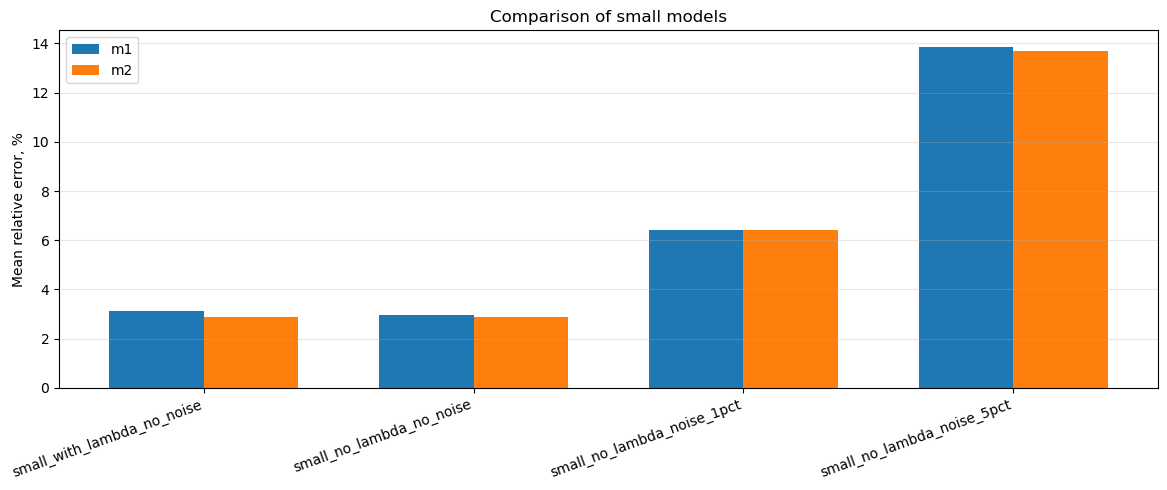

In [33]:
plt.figure(figsize=(12, 5))

x = np.arange(len(full_comparison_df))
width = 0.35

plt.bar(
    x - width / 2,
    full_comparison_df["m1_mean_relative_error_percent"],
    width,
    label="m1",
)

plt.bar(
    x + width / 2,
    full_comparison_df["m2_mean_relative_error_percent"],
    width,
    label="m2",
)

plt.xticks(
    x,
    full_comparison_df["experiment"],
    rotation=20,
    ha="right",
)
plt.ylabel("Mean relative error, %")
plt.title("Comparison of small models")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Вывод по дополнительному сравнению

Контрольный эксперимент с 11 признаками без шума показывает качество предыдущей маленькой модели. Эксперимент с 9 признаками без шума отдельно показывает эффект удаления `lambda1`, `lambda2`. Сравнение с вариантами шума `1%` и `5%` показывает, насколько именно измерительный шум ухудшает восстановление параметров.